In [ ]:
from imblearn.ensemble import RUSBoostClassifier
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (fbeta_score, average_precision_score, precision_recall_curve, 
                             make_scorer)
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from utilities.constants import IMPORTANT_FEATURES
from utilities.metrics import evaluate_model
from utilities.preprocess import preprocess_data, fillna, one_hot_encode, add_new_features, remove_top_percentile

In [2]:
datasets = {
    'train': pd.read_excel('data/Training.xlsx'),
    'test': pd.read_excel('data/Test.xlsx')
}

1. Бінарныя катэгарыяльныя класы закадуем нулямі і адзінкамі.
2. Колькасць утрыманцаў закадуем паслядоўнымі лічбамі 0, 1, 2, 3, 4. 
3. Адукацыю таксама паслядоўнымі лічбамі: 0, 1, 2. З ідэяй, што базавая адукацыя гэта меньш, чым сярэдне-спецыяльная, а сярэдне-спецыяльная і няпоўная вышэйшая гэта меньш, чым вышэйшая.

In [3]:
datasets = {
    data_type: preprocess_data(data)
    for data_type, data in datasets.items()
}

Дададзім дадатковыя прыкметы:
1. has_dependents: ці ёсць утрыманцы
2. H_bigger_than_zero: ці вышэй за нуль прыкмета 'H'
3. is_single: ці з'яўляецца чалавек адзінокім

In [4]:
datasets = {
    data_type: add_new_features(data)
    for data_type, data in datasets.items()
}

In [5]:
features = {
    data_type: data.drop(columns=['target'])
    for data_type, data in datasets.items()
}

targets = {
    data_type: data['target']
    for data_type, data in datasets.items()
}

Запоўнім прапушчанныя значэнні: для безперапынных прыкмет медыяная размеркавання, для катэгарыяльных - модай.

In [6]:
processed_features = fillna(features)

Закадуем небінарныя катэгарыяльныя пераменныя праз one-hot-encoding.

In [7]:
processed_features = {
    data_type: one_hot_encode(data)
    for data_type, data in processed_features.items()
}

In [8]:
processed_features = {
    data_type: data[IMPORTANT_FEATURES].copy()
    for data_type, data in processed_features.items()
}

Для вырашэння задачы выкарыстаю наступныя алгарытмы:
1. Лагістычная рэгрэсія
2. Выпадковы лес
3. Rusboost - бустынг-алгарытм з убудаваным андэрсамплінгам для паляпшэння вынікаў для задач з несбалансаванымі класамі

Ажыцявім пошук аптымальных гіперпараметраў, для лагістычнай рэгрэсіі пошукам па сетцы. Для астатніх выпадковым пошукам. 

У якасці параметра ацэнкі выкарыстаем f2-меру.

In [9]:
ftwo_scorer = make_scorer(fbeta_score, beta=2)

In [ ]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": ['balanced', {0: 1, 1: 10}, {0: 1, 1: 20}, {0: 1, 1: 50}, {0: 1, 1: 75}]
}

grid = GridSearchCV(
    LogisticRegression(class_weight="balanced"),
    param_grid,
    scoring=ftwo_scorer,
    cv=5,
    n_jobs=-1
)

scaler = StandardScaler()

grid.fit(scaler.fit_transform(processed_features['train']), targets['train'])

grid.best_estimator_

In [ ]:
param_grid_rf = {
    "n_estimators": [50, 100, 200, 300, 400, 600, 800],
    "max_depth": [5, 10, 20, 30, 50, 100, 200, None],
    "min_samples_leaf": [20, 30, 40, 50, 80, 100],
    "max_features": ["sqrt", "log2"],
    "class_weight": ['balanced_subsample', {0: 1, 1: 50}, {0: 1, 1: 75}, {0: 1, 1: 100}, {0: 1, 1: 150}, {0: 1, 1: 200}, {0: 1, 1: 250}]
}

grid = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample"),
    param_grid_rf,
    scoring=ftwo_scorer,
    cv=5,
    n_jobs=-1
)

grid.fit(processed_features['train'], targets['train'])

grid.best_estimator_

In [ ]:
param_grid_rus = {
    "n_estimators": [100, 200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1, 0.5],
    "estimator__max_depth": [2, 3, 5, 10, 20],
    "estimator__min_samples_leaf": [1, 2, 3, 5, 10]
}

grid = RandomizedSearchCV(
    RUSBoostClassifier(
        estimator=DecisionTreeClassifier(
            random_state=42
        ),
        random_state=42
    ),
    param_grid_rus,
    scoring=ftwo_scorer,
    cv=5,
    n_jobs=-1
)

grid.fit(processed_features['train'], targets['train'])

grid.best_estimator_

In [ ]:
param_dist = {
    'n_estimators': randint(100, 800),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.29),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),            
    'colsample_bytree': uniform(0.6, 0.4), 
    'gamma': uniform(0, 5),
    'reg_lambda': uniform(0.5, 5),
    'scale_pos_weight': [20, 50, 100, 150, 200, 250]
}

grid = RandomizedSearchCV(
    XGBClassifier(
        random_state=42
    ),
    param_dist,
    scoring=ftwo_scorer,
    cv=5,
    n_jobs=-1
)

grid.fit(processed_features['train'], targets['train'])

grid.best_estimator_

Алгарытмы на базе дрэваў рашэнняў дапоўнім калібратарам сігмоіды, для карэктнай інтэрпрэтацыі выхаду мадэляў як імавернасці.

In [30]:
models = {
    "Logistic Regression": 
    Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight={0: 1, 1: 50},
                C=0.01,
                max_iter=1000,
                random_state=42
            )
        )
    ]),   
    "Random Forest": 
    CalibratedClassifierCV(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=100,
            min_samples_leaf=50,
            max_features="log2",
            class_weight={0: 1, 1: 200},
            random_state=42,
            n_jobs=-1
        ),
        method="sigmoid",
        cv=5
    ),

    "RUSBoost": 
    CalibratedClassifierCV(
        RUSBoostClassifier(
            estimator=DecisionTreeClassifier(
                max_depth=10,
                min_samples_leaf=2,
                random_state=42
            ),
            learning_rate=0.05,
            n_estimators=400,
            random_state=42,
        ),
        method="sigmoid",
        cv=5
    ),
    "XGBoost":
    CalibratedClassifierCV(
        XGBClassifier(
            objective='binary:logistic',
            n_estimators=236,
            learning_rate=0.035,
            max_depth=4,
            colsample_bytree=0.94,
            gamma=1.33,
            scale_pos_weight=100,
            random_state=42,
            eval_metric='logloss',
            reg_lambda=0.7,
            subsample=0.9
        )
    )
}

Для вызначэння найлепшай мадэлі ажыцявім крос-валідацыю на 5 фалдах.
На кожнай ітэрацыі:
1. Чатыры фалда выкарыстоўваюцца як трэніровачная выбарка, а пяты як валідацыйная.
2. Адбываецца запаўненне прапушчаных значэнняў, падбор шкаліроўшчыка і навучанне мадэляў толькі на трэніровачных фалдах.
3. Падбіраецца аптымальны парог (па максімізацыі f2-меры) толькі для цяперашняй ітэрацыі для раздзялення па мэтавым класам.
4. Збіраюцца прадказанні мадэляў па розным фалдам.
Пасля цыкла па прадказанням сярод усіх фалдоў разлічваюцца метрыкі і падбіраецца парог, які будзе выкарыстоўвацца фінальнай мадэллю.

In [31]:
results = []
best_thresholds = {}

cross_validation_folds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for model_name, model in models.items():
    split_positions = cross_validation_folds.split(features['train'], targets['train'])

    probabilities = []
    actuals = []
    predictions = []

    for train_idx, valid_idx in split_positions:
        X_train = features['train'].iloc[train_idx]
        X_valid = features['train'].iloc[valid_idx]

        y_train = targets['train'].iloc[train_idx]
        y_valid = targets['train'].iloc[valid_idx]

        X_train = add_new_features(X_train)
        X_valid = add_new_features(X_valid)

        X_train = fillna({'train': X_train, 'test': X_valid})['train']
        X_valid = fillna({'train': X_train, 'test': X_valid})['test']

        X_train = one_hot_encode(X_train)
        X_valid = one_hot_encode(X_valid)

        X_train = X_train[IMPORTANT_FEATURES].copy()
        X_valid = X_valid[IMPORTANT_FEATURES].copy()

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_valid)[:, 1]

        precision, recall, thresholds = precision_recall_curve(
            y_valid,
            y_prob
        )

        f2_scores = (
            5 * precision[:-1] * recall[:-1]
        ) / (
            4 * precision[:-1] + recall[:-1] + 1e-10
        )

        threshold = thresholds[np.argmax(f2_scores)]
        y_pred = (y_prob >= threshold).astype(int)

        probabilities = probabilities + y_prob.tolist()
        actuals = actuals + y_valid.tolist()
        predictions = predictions + y_pred.tolist()   

    precision, recall, thresholds = precision_recall_curve(
        actuals,
        probabilities
    )

    f2_scores = (
        5 * precision[:-1] * recall[:-1]
    ) / (
        4 * precision[:-1] + recall[:-1] + 1e-10
    )

    best_thresholds[model_name] = thresholds[np.argmax(f2_scores)]

    results.append({
        "model": model_name,
        "PR_AUC": average_precision_score(
            actuals,
            probabilities
        ),
        "F2": fbeta_score(
            actuals,
            predictions,
            beta=2
        ),
        "threshold": best_thresholds[model_name]
    })         
        

In [32]:
results = pd.DataFrame(results)
results

,model,PR_AUC,F2,threshold
0,Logistic Regression,0.040429,0.161503,0.615794
1,Random Forest,0.041561,0.157410,0.028878
2,RUSBoost,0.039711,0.184796,0.033632
3,XGBoost,0.042007,0.164902,0.036244


Лепшая мадэль вызначаецца па самай вялікай f2-меры сярод усіх фалдоў.

Гэта мадэль навучаецца на ўсёй трэніровачнай выбарцы, у якасці парога выкарыстоўваецца значэнне падабранае падчас крос-валідацыі.

In [33]:
selection_metric = 'F2'
best_model = results[results[selection_metric] == results[selection_metric].max()]['model'].iloc[0]

final_model = models[best_model]
    
final_model.fit(processed_features['train'], targets['train'])

y_prob = final_model.predict_proba(processed_features['test'])[:, 1]

y_pred = (y_prob >= best_thresholds[best_model]).astype(int)
best_model

'RUSBoost'

F2 Score: 0.1789
Average Precision: 0.0242
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     38259
           1       0.06      0.38      0.10       146

    accuracy                           0.97     38405
   macro avg       0.53      0.68      0.54     38405
weighted avg       0.99      0.97      0.98     38405



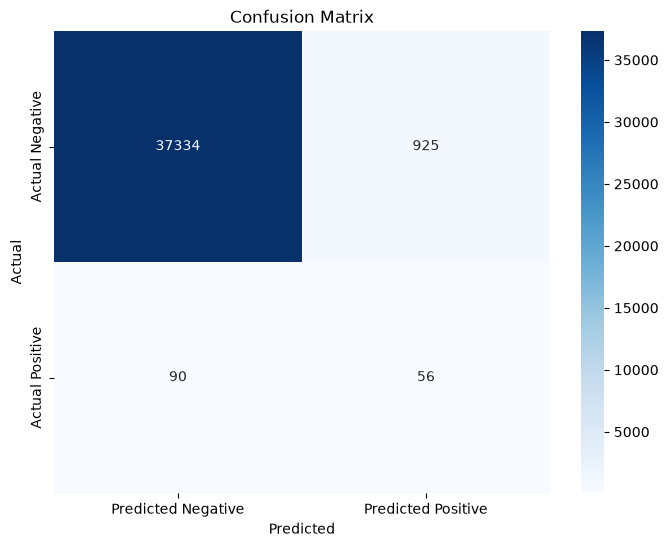

In [34]:
evaluate_model(targets['test'], y_pred)

Мадэль можна даналадзіць, у выпадку, калі патрэбна прапусціць вялікую колькасць кліентаў і адкінуць толькі самых рызыкоўных, або наадварот: зрабіць вельмі асцярожную і пераборлівую мадэль з мінімальнай колькасцю нераспазнаных дэфолтаў.